# Proyecto Final · Machine Learning
## Segmentación de jugadores de fútbol por perfil técnico
### Aprendizaje No Supervisado — Reducción de dimensionalidad (PCA) + Clustering

---

### Planteamiento del problema

Un departamento de **scouting** necesita identificar **perfiles de jugador** dentro de una base
de datos de casi 17.000 futbolistas. El problema es que cada jugador está descrito por **28
atributos técnicos** (regate, pases, entradas, velocidad, fuerza, visión de juego...), lo que
hace imposible compararlos "a ojo".

La pregunta de negocio es:

> **¿Existen arquetipos naturales de jugador que emerjan de los datos, sin decirle al modelo
> en qué posición juega cada uno?**

Si esos grupos existen, el scouting puede usarlos para buscar **reemplazos con perfil similar**,
detectar **jugadores polivalentes** o encontrar **promesas jóvenes** con el perfil técnico de un
titular consolidado.

### ¿Por qué aprendizaje no supervisado?

No tenemos una variable objetivo que queramos predecir. Queremos **descubrir estructura oculta**
en los datos. Por eso este es un problema de **clustering**, no de clasificación.

Un detalle metodológico importante: **la posición real del jugador NO se usa para entrenar**.
La reservamos para *validar* al final si los grupos que el modelo encontró tienen sentido
futbolístico. Esto convierte una tarea no supervisada en algo verificable.

### Flujo de trabajo

| Etapa | Qué se hace |
|-------|-------------|
| 1. Exploración | Entender el dataset, distribuciones y correlaciones |
| 2. Preprocesamiento | Filtrar porteros, seleccionar atributos, estandarizar |
| 3. PCA | Reducir 28 dimensiones y **entender qué significa cada componente** |
| 4. Modelado | Comparar **3 algoritmos de clustering** de familias distintas |
| 5. Evaluación | Silhouette, Davies-Bouldin y Calinski-Harabasz |
| 6. Interpretación | Perfilar cada grupo y validarlo contra las posiciones reales |

**Dataset:** [FIFA 21 Complete Player Dataset](https://www.kaggle.com/datasets/stefanoleone992/fifa-21-complete-player-dataset) — archivo `players_21.csv`.


In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y reducción de dimensionalidad
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Los tres algoritmos de clustering que vamos a comparar
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Métricas de evaluación para clustering
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score)

# Dendrograma para el clustering jerárquico
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


---
## 1. Exploración de datos (EDA)

Cargamos el dataset y entendemos qué información contiene antes de tocar nada.

In [2]:
# Carga del dataset
df = pd.read_csv("players_21.csv", low_memory=False)

print(f"El dataset tiene {df.shape[0]:,} jugadores y {df.shape[1]} columnas.")
df[["short_name", "age", "overall", "club_name", "player_positions"]].head(10)


El dataset tiene 18,944 jugadores y 106 columnas.


,short_name,age,overall,club_name,player_positions
0,L. Messi,33,93,FC Barcelona,"RW, ST, CF"
1,Cristiano Ronaldo,35,92,Juventus,"ST, LW"
2,J. Oblak,27,91,Atlético Madrid,GK
3,R. Lewandowski,31,91,FC Bayern München,ST
4,Neymar Jr,28,91,Paris Saint-Germain,"LW, CAM"
5,K. De Bruyne,29,91,Manchester City,"CAM, CM"
6,K. Mbappé,21,90,Paris Saint-Germain,"ST, LW, RW"
7,M. ter Stegen,28,90,FC Barcelona,GK
8,V. van Dijk,28,90,Liverpool,CB
9,Alisson,27,90,Liverpool,GK


In [3]:
# Los 28 atributos técnicos que describen a cada jugador.
# Son las variables con las que trabajará el modelo.
ATRIBUTOS = [
    # Ataque
    "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy",
    "attacking_short_passing", "attacking_volleys",
    # Habilidad técnica
    "skill_dribbling", "skill_curve", "skill_fk_accuracy",
    "skill_long_passing", "skill_ball_control",
    # Movimiento
    "movement_acceleration", "movement_sprint_speed", "movement_agility",
    "movement_reactions", "movement_balance",
    # Potencia
    "power_shot_power", "power_jumping", "power_stamina",
    "power_strength", "power_long_shots",
    # Mentalidad
    "mentality_aggression", "mentality_interceptions", "mentality_positioning",
    "mentality_vision", "mentality_penalties", "mentality_composure",
    # Defensa
    "defending_standing_tackle", "defending_sliding_tackle",
]

print(f"Trabajaremos con {len(ATRIBUTOS)} atributos técnicos.")
print("\nTodos están en la misma escala teórica (1-99), pero con distinta media y dispersión,")
print("por lo que igualmente habrá que estandarizarlos antes del PCA.")


Trabajaremos con 28 atributos técnicos.

Todos están en la misma escala teórica (1-99), pero con distinta media y dispersión,
por lo que igualmente habrá que estandarizarlos antes del PCA.


In [4]:
# Estadísticos descriptivos de los atributos técnicos
df[ATRIBUTOS].describe().T[["mean", "std", "min", "max"]].round(1)


,mean,std,min,max
attacking_crossing,49.6,18.2,6.0,94.0
attacking_finishing,45.8,19.6,3.0,95.0
attacking_heading_accuracy,51.9,17.3,5.0,93.0
attacking_short_passing,58.7,14.6,7.0,94.0
attacking_volleys,42.7,17.7,3.0,90.0
skill_dribbling,55.5,18.8,5.0,96.0
skill_curve,47.2,18.2,4.0,94.0
skill_fk_accuracy,42.4,17.2,5.0,94.0
skill_long_passing,52.7,15.2,5.0,93.0
skill_ball_control,58.5,16.6,5.0,96.0


### Control de calidad de los datos

Antes de modelar hay que **verificar**, no asumir, que los datos están en condiciones. Reviso
cuatro cosas: nulos, duplicados, rangos válidos y forma de las distribuciones.

In [5]:
# --- 1. Valores nulos ---
nulos = df[ATRIBUTOS].isnull().sum()
print("1) VALORES NULOS")
if nulos.sum() == 0:
    print("   No hay valores nulos en los 28 atributos técnicos.")
    print("   -> No se requiere imputación. Es un resultado verificado, no un supuesto:")
    print("      los ratings de FIFA están completos por diseño para jugadores de campo.")
else:
    print(nulos[nulos > 0])


1) VALORES NULOS
   No hay valores nulos en los 28 atributos técnicos.
   -> No se requiere imputación. Es un resultado verificado, no un supuesto:
      los ratings de FIFA están completos por diseño para jugadores de campo.


In [6]:
# --- 2. Registros duplicados ---
print("2) DUPLICADOS")
dup_completos = df.duplicated().sum()
dup_perfil = df.duplicated(subset=["short_name"] + ATRIBUTOS).sum()
print(f"   Filas completamente duplicadas:              {dup_completos}")
print(f"   Jugadores repetidos con perfil idéntico:     {dup_perfil}")
print("   -> No hay duplicados que eliminar.")
print()
print("   Nota: dos jugadores DISTINTOS pueden compartir los mismos 28 valores por azar.")
print("   Eso no es un duplicado sino una coincidencia legítima, y no debe eliminarse:")
print("   el clustering justamente busca agrupar perfiles similares.")


2) DUPLICADOS


   Filas completamente duplicadas:              0
   Jugadores repetidos con perfil idéntico:     0
   -> No hay duplicados que eliminar.

   Nota: dos jugadores DISTINTOS pueden compartir los mismos 28 valores por azar.
   Eso no es un duplicado sino una coincidencia legítima, y no debe eliminarse:
   el clustering justamente busca agrupar perfiles similares.


In [7]:
# --- 3. Rangos válidos ---
print("3) RANGOS VÁLIDOS")
fuera_rango = ((df[ATRIBUTOS] < 1) | (df[ATRIBUTOS] > 99)).sum().sum()
print(f"   Valores fuera del rango teórico 1-99: {int(fuera_rango)}")
print(f"   Mínimo global observado: {df[ATRIBUTOS].min().min():.0f}")
print(f"   Máximo global observado: {df[ATRIBUTOS].max().max():.0f}")
print("   -> Todos los valores son coherentes con la escala del dataset.")


3) RANGOS VÁLIDOS
   Valores fuera del rango teórico 1-99: 0
   Mínimo global observado: 2
   Máximo global observado: 97
   -> Todos los valores son coherentes con la escala del dataset.


In [8]:
# --- 4. Forma de las distribuciones (asimetría) ---
asimetria = df[ATRIBUTOS].skew()
fuertes = asimetria[asimetria.abs() > 1]

print("4) ASIMETRÍA (SKEWNESS)")
print(f"   Asimetría absoluta media:            {asimetria.abs().mean():.2f}")
print(f"   Atributos con asimetría fuerte (>1): {len(fuertes)} de {len(ATRIBUTOS)}")
if len(fuertes) > 0:
    print("   Atributos afectados:")
    for nombre, valor in fuertes.items():
        print(f"      {nombre:<32} {valor:+.2f}")
print()
print("   -> La mayoría de distribuciones son aproximadamente simétricas.")
print()
if len(fuertes) > 0 and (fuertes < 0).all():
    print("   HALLAZGO IMPORTANTE: todos los atributos asimétricos tienen asimetría NEGATIVA,")
    print("   es decir, una cola hacia valores bajos. Y no es casualidad cuáles son: se trata")
    print("   de habilidades TÉCNICAS básicas que casi cualquier jugador de campo domina")
    print("   razonablemente bien. La cola la produce una minoría con valores muy bajos.")
    print()
    print("   Esa minoría son los PORTEROS, que aún están incluidos en este cálculo y")
    print("   puntúan artificialmente bajo en atributos de campo. Es decir: el EDA anticipa")
    print("   y refuerza la primera decisión de preprocesamiento, que será excluirlos.")
print()
print("   Implicaciones para el modelado:")
print("      (a) PCA se apoya en la varianza y funciona mejor sin asimetrías extremas;")
print("      (b) no hace falta aplicar transformaciones logarítmicas ni Box-Cox;")
print("      (c) el supuesto gaussiano del modelo GMM es razonable en estos datos.")


4) ASIMETRÍA (SKEWNESS)
   Asimetría absoluta media:            0.55
   Atributos con asimetría fuerte (>1): 3 de 28
   Atributos afectados:
      attacking_short_passing          -1.15
      skill_dribbling                  -1.13
      skill_ball_control               -1.34

   -> La mayoría de distribuciones son aproximadamente simétricas.

   HALLAZGO IMPORTANTE: todos los atributos asimétricos tienen asimetría NEGATIVA,
   es decir, una cola hacia valores bajos. Y no es casualidad cuáles son: se trata
   de habilidades TÉCNICAS básicas que casi cualquier jugador de campo domina
   razonablemente bien. La cola la produce una minoría con valores muy bajos.

   Esa minoría son los PORTEROS, que aún están incluidos en este cálculo y
   puntúan artificialmente bajo en atributos de campo. Es decir: el EDA anticipa
   y refuerza la primera decisión de preprocesamiento, que será excluirlos.

   Implicaciones para el modelado:
      (a) PCA se apoya en la varianza y funciona mejor sin asime

In [9]:
# Comprobación de la hipótesis anterior: ¿la asimetría desaparece al excluir porteros?
sin_gk = df[~df["player_positions"].str.contains("GK")]
asim_sin_gk = sin_gk[ATRIBUTOS].skew()

comparacion_skew = pd.DataFrame({
    "Con porteros": asimetria.abs().round(2),
    "Sin porteros": asim_sin_gk.abs().round(2),
})
comparacion_skew["Mejora"] = (comparacion_skew["Con porteros"]
                              - comparacion_skew["Sin porteros"]).round(2)

print("VERIFICACIÓN DE LA HIPÓTESIS")
print("-" * 56)
print(f"  Asimetría media CON porteros:  {asimetria.abs().mean():.2f}")
print(f"  Asimetría media SIN porteros:  {asim_sin_gk.abs().mean():.2f}")
print(f"  Atributos con |skew| > 1 CON porteros: {(asimetria.abs() > 1).sum()}")
print(f"  Atributos con |skew| > 1 SIN porteros: {(asim_sin_gk.abs() > 1).sum()}")
print("-" * 56)
print()
print("Los 5 atributos que más mejoran al excluir porteros:")
print(comparacion_skew.nlargest(5, "Mejora").to_string())
print()
print("Conclusión: la hipótesis se confirma. Excluir a los porteros no es una decisión")
print("arbitraria — está respaldada por evidencia del propio análisis exploratorio.")


VERIFICACIÓN DE LA HIPÓTESIS
--------------------------------------------------------
  Asimetría media CON porteros:  0.55
  Asimetría media SIN porteros:  0.37
  Atributos con |skew| > 1 CON porteros: 3
  Atributos con |skew| > 1 SIN porteros: 0
--------------------------------------------------------

Los 5 atributos que más mejoran al excluir porteros:
                            Con porteros  Sin porteros  Mejora
skill_ball_control                  1.34          0.52    0.82
attacking_heading_accuracy          0.86          0.10    0.76
attacking_short_passing             1.15          0.54    0.61
power_stamina                       0.89          0.39    0.50
mentality_composure                 0.44          0.02    0.42

Conclusión: la hipótesis se confirma. Excluir a los porteros no es una decisión
arbitraria — está respaldada por evidencia del propio análisis exploratorio.


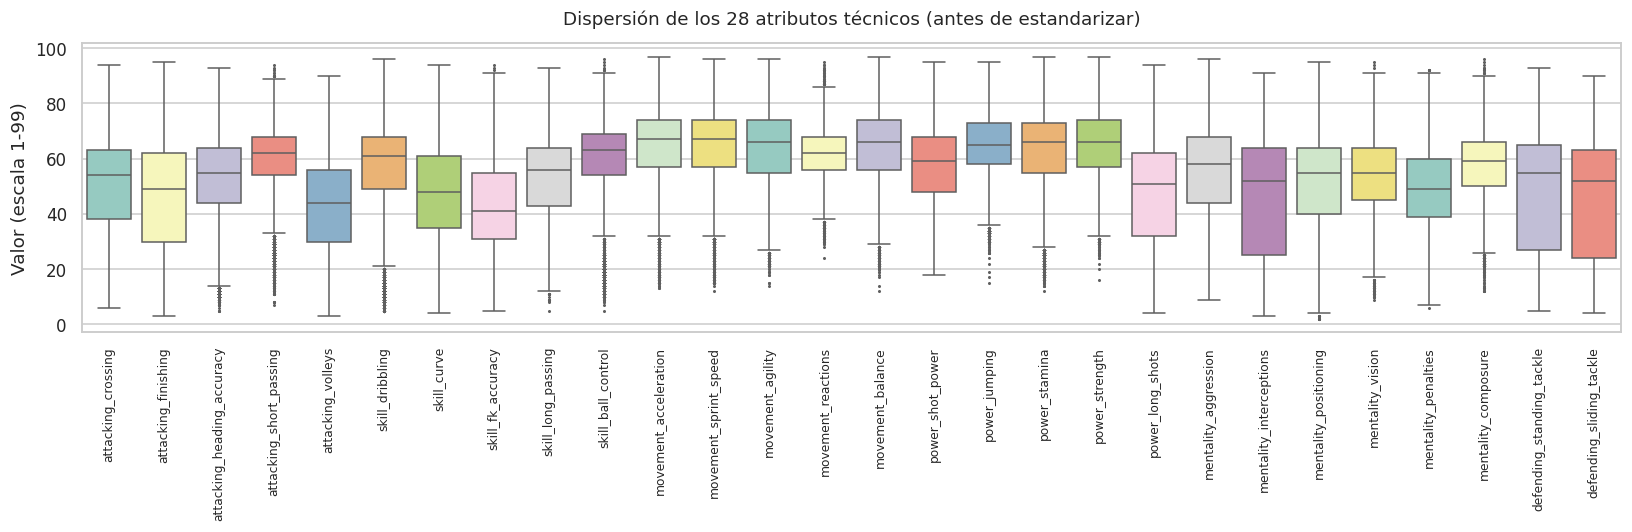

Observación clave: aunque todos comparten la escala 1-99, sus MEDIANAS y
DISPERSIONES son muy distintas. Por ejemplo, los atributos defensivos se reparten
por casi todo el rango, mientras que 'movement_reactions' se concentra en el centro.

Esa diferencia de varianza es la razón por la que hay que estandarizar antes del PCA:
sin hacerlo, los atributos más dispersos dominarían los componentes por su escala
y no por su relevancia real.

Sobre los puntos que aparecen fuera de los bigotes: NO son errores a eliminar.
Son jugadores de élite con valores extremos legítimos (por ejemplo, un delantero
con 95 en definición). Eliminarlos borraría justamente los perfiles más interesantes.


In [10]:
# Visualización de la dispersión de los atributos.
# Sirve para detectar valores atípicos y confirmar que ninguno domina por escala.
plt.figure(figsize=(15, 5))
sns.boxplot(data=df[ATRIBUTOS], palette="Set3", fliersize=1)
plt.title("Dispersión de los 28 atributos técnicos (antes de estandarizar)", pad=12)
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Valor (escala 1-99)")
plt.tight_layout()
plt.show()

print("Observación clave: aunque todos comparten la escala 1-99, sus MEDIANAS y")
print("DISPERSIONES son muy distintas. Por ejemplo, los atributos defensivos se reparten")
print("por casi todo el rango, mientras que 'movement_reactions' se concentra en el centro.")
print()
print("Esa diferencia de varianza es la razón por la que hay que estandarizar antes del PCA:")
print("sin hacerlo, los atributos más dispersos dominarían los componentes por su escala")
print("y no por su relevancia real.")
print()
print("Sobre los puntos que aparecen fuera de los bigotes: NO son errores a eliminar.")
print("Son jugadores de élite con valores extremos legítimos (por ejemplo, un delantero")
print("con 95 en definición). Eliminarlos borraría justamente los perfiles más interesantes.")


### Distribución de las variables de contexto

Estas variables (edad, valoración general, posición) **no entran al modelo**, pero nos ayudan
a entender la población y luego a interpretar los grupos.

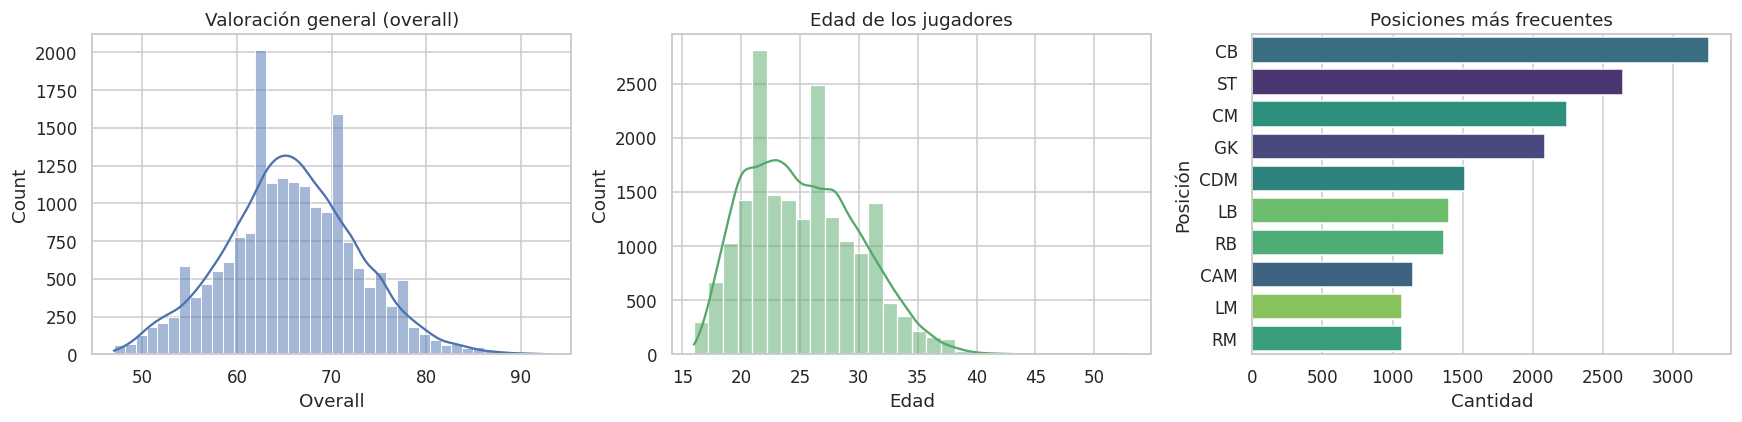

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df["overall"], bins=40, kde=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Valoración general (overall)")
axes[0].set_xlabel("Overall")

sns.histplot(df["age"], bins=30, kde=True, ax=axes[1], color="#55a868")
axes[1].set_title("Edad de los jugadores")
axes[1].set_xlabel("Edad")

# Posición principal = la primera que aparece en player_positions
pos_principal = df["player_positions"].str.split(",").str[0].str.strip()
orden_pos = pos_principal.value_counts().head(10).index
sns.countplot(y=pos_principal, order=orden_pos, ax=axes[2],
              hue=pos_principal, palette="viridis", legend=False)
axes[2].set_title("Posiciones más frecuentes")
axes[2].set_xlabel("Cantidad")
axes[2].set_ylabel("Posición")

plt.tight_layout()
plt.show()


### Correlación entre atributos: la justificación del PCA

Este es el gráfico **más importante del EDA** para este proyecto. Si los 28 atributos fueran
independientes entre sí, reducir dimensiones destruiría información. Veamos si ese es el caso.

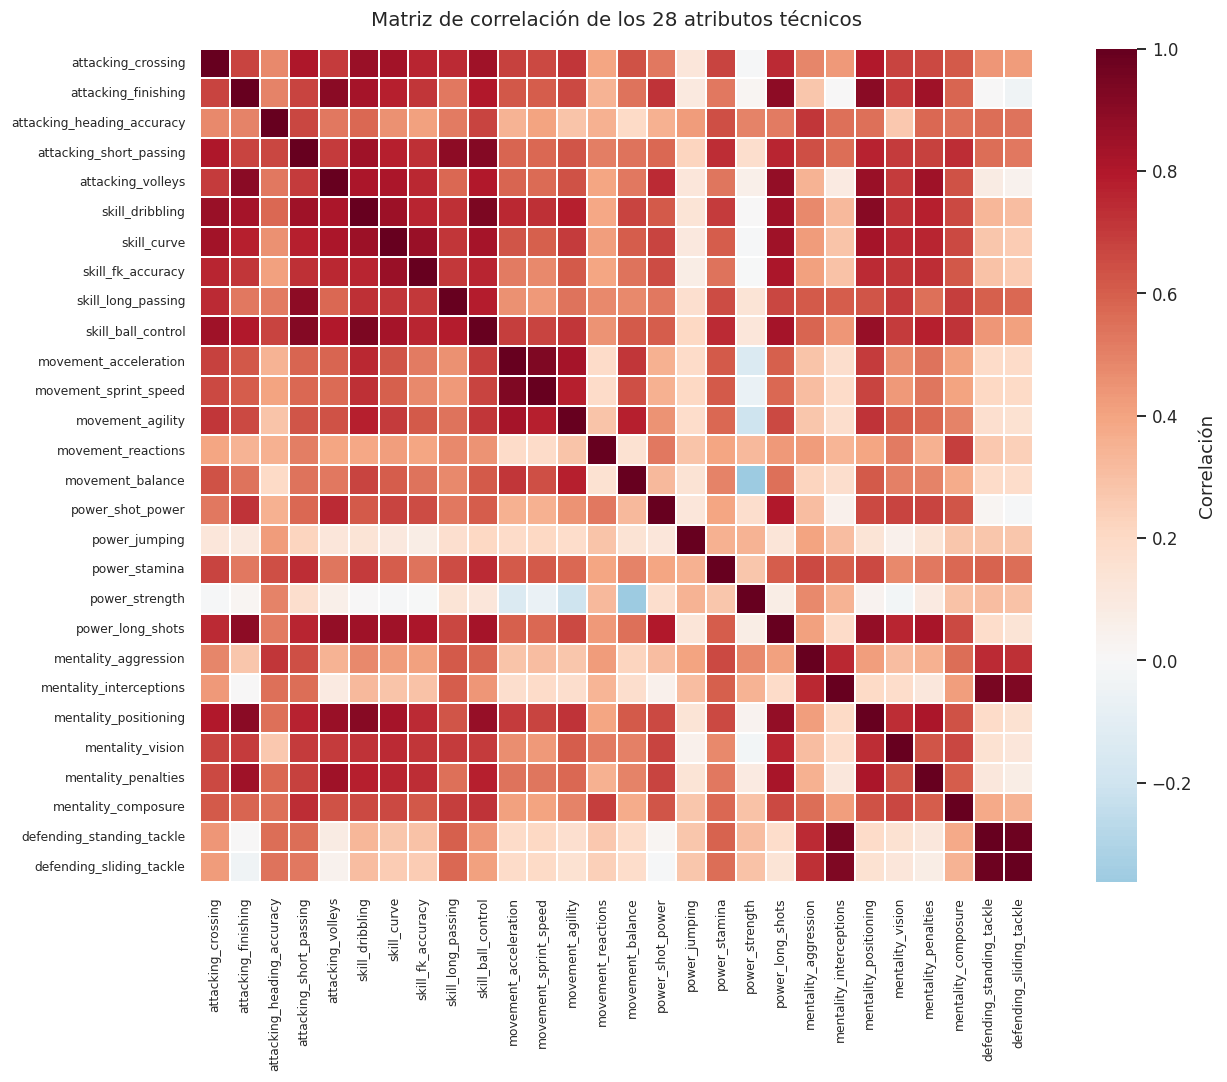

Pares de atributos con correlación absoluta > 0.7: 89

Se observan bloques claros de variables muy correlacionadas entre sí
(por ejemplo, todas las defensivas juntas y todas las de ataque juntas).
Esa redundancia es exactamente lo que PCA aprovecha para comprimir la información.


In [12]:
plt.figure(figsize=(13, 10))
corr = df[ATRIBUTOS].corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, square=True,
            linewidths=0.3, cbar_kws={"label": "Correlación"},
            xticklabels=True, yticklabels=True)
plt.title("Matriz de correlación de los 28 atributos técnicos", fontsize=13, pad=15)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Cuantificamos cuánta redundancia hay
corr_abs = corr.abs().to_numpy(copy=True)
np.fill_diagonal(corr_abs, np.nan)
altas = np.nansum(corr_abs > 0.7) / 2
print(f"Pares de atributos con correlación absoluta > 0.7: {int(altas)}")
print("\nSe observan bloques claros de variables muy correlacionadas entre sí")
print("(por ejemplo, todas las defensivas juntas y todas las de ataque juntas).")
print("Esa redundancia es exactamente lo que PCA aprovecha para comprimir la información.")


---
## 2. Preprocesamiento

Tres decisiones, cada una con su justificación:

**1. Excluir a los porteros.** Los arqueros se evalúan con atributos completamente distintos
(paradas, reflejos, saque). Si los dejamos, el modelo gastará su primer componente en separar
"portero vs. no portero", que es algo que ya sabemos. Excluirlos permite que el análisis se
concentre en distinguir perfiles **entre jugadores de campo**, que es lo realmente interesante.

**2. Usar solo atributos técnicos.** Dejamos fuera valor de mercado, salario o club: son
consecuencias del rendimiento o del contexto económico, no descripciones del **estilo de juego**.

**3. Estandarizar (`StandardScaler`).** PCA se basa en la varianza. Sin estandarizar, un atributo
con mayor dispersión dominaría los componentes solo por su escala, no por su importancia real.

In [13]:
# --- Decisión 1: excluir porteros ---
es_portero = df["player_positions"].str.contains("GK")
datos = df[~es_portero].copy().reset_index(drop=True)

print(f"Jugadores totales:     {len(df):,}")
print(f"Porteros excluidos:    {es_portero.sum():,}")
print(f"Jugadores de campo:    {len(datos):,}")


Jugadores totales:     18,944
Porteros excluidos:    2,084
Jugadores de campo:    16,860


In [14]:
# --- Decisión 2: matriz de trabajo solo con atributos técnicos ---
X = datos[ATRIBUTOS].copy()

# Guardamos aparte las variables de contexto para la interpretación posterior.
# IMPORTANTE: estas NO entran al modelo.
contexto = datos[["short_name", "age", "overall", "potential",
                  "club_name", "league_name", "player_positions"]].copy()
contexto["posicion"] = contexto["player_positions"].str.split(",").str[0].str.strip()

print(f"Matriz de trabajo X: {X.shape[0]:,} filas × {X.shape[1]} atributos")
print(f"Valores nulos en X: {X.isnull().sum().sum()}")


Matriz de trabajo X: 16,860 filas × 28 atributos
Valores nulos en X: 0


In [15]:
# --- Decisión 3: estandarización ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos estandarizados (media 0, desviación 1).")
print(f"Media promedio tras escalar:      {X_scaled.mean():.6f}")
print(f"Desviación promedio tras escalar: {X_scaled.std():.6f}")


Datos estandarizados (media 0, desviación 1).
Media promedio tras escalar:      0.000000
Desviación promedio tras escalar: 1.000000


---
## 3. Reducción de dimensionalidad con PCA

Ahora aplicamos PCA. El objetivo no es solo comprimir: también queremos **entender qué
representa cada componente** en términos futbolísticos.

In [16]:
# Ajustamos PCA con todos los componentes para estudiar la varianza explicada
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

resumen = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(8)],
    "Varianza explicada": var_exp[:8],
    "Varianza acumulada": var_acum[:8],
})
resumen.style.format({"Varianza explicada": "{:.1%}", "Varianza acumulada": "{:.1%}"})


,Componente,Varianza explicada,Varianza acumulada
0,PC1,41.0%,41.0%
1,PC2,20.0%,60.9%
2,PC3,10.1%,71.0%
3,PC4,6.1%,77.2%
4,PC5,2.7%,79.8%
5,PC6,2.3%,82.2%
6,PC7,2.0%,84.1%
7,PC8,1.6%,85.7%


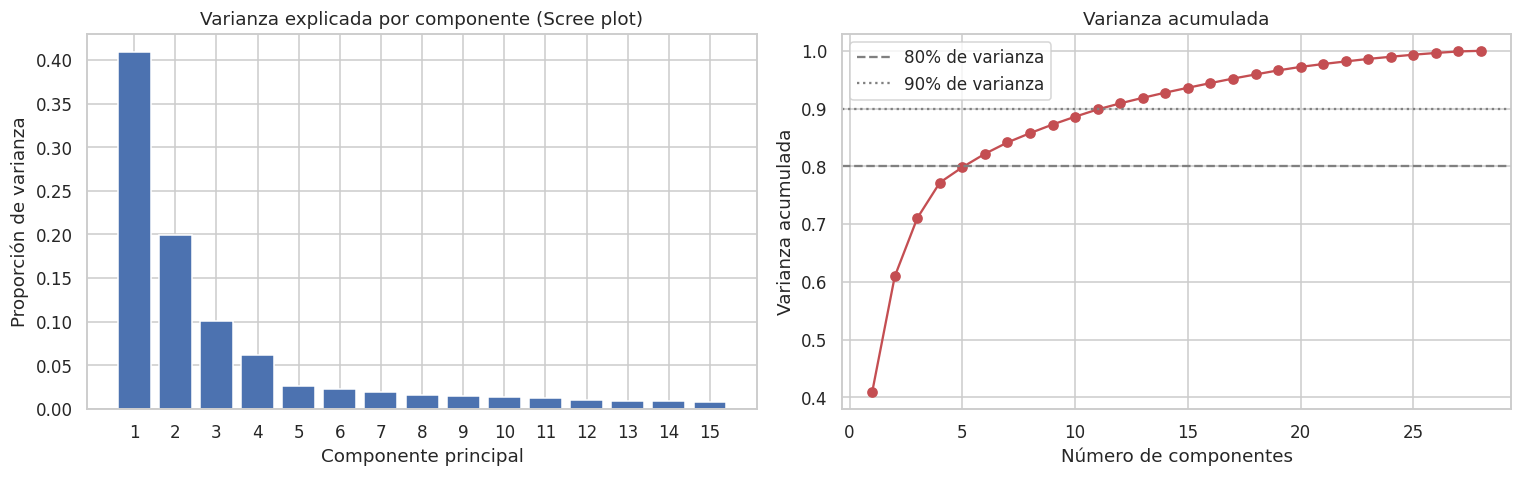

Componentes necesarios para explicar el 80% de la varianza: 6
Componentes necesarios para explicar el 90% de la varianza: 12

Los 3 primeros componentes ya explican el 71.0% de la varianza total,
partiendo de 28 atributos originales.


In [17]:
# Scree plot: varianza explicada individual y acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

n_ver = 15
axes[0].bar(range(1, n_ver + 1), var_exp[:n_ver], color="#4c72b0")
axes[0].set_title("Varianza explicada por componente (Scree plot)")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Proporción de varianza")
axes[0].set_xticks(range(1, n_ver + 1))

axes[1].plot(range(1, len(var_acum) + 1), var_acum, marker="o", color="#c44e52")
axes[1].axhline(0.80, ls="--", color="gray", label="80% de varianza")
axes[1].axhline(0.90, ls=":", color="gray", label="90% de varianza")
axes[1].set_title("Varianza acumulada")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada")
axes[1].legend()

plt.tight_layout()
plt.show()

n_80 = int(np.argmax(var_acum >= 0.80) + 1)
n_90 = int(np.argmax(var_acum >= 0.90) + 1)
print(f"Componentes necesarios para explicar el 80% de la varianza: {n_80}")
print(f"Componentes necesarios para explicar el 90% de la varianza: {n_90}")
print(f"\nLos 3 primeros componentes ya explican el {var_acum[2]:.1%} de la varianza total,")
print(f"partiendo de {len(ATRIBUTOS)} atributos originales.")


### ¿Qué significa cada componente?

Un componente principal es una combinación de los atributos originales. Los **loadings**
(pesos) nos dicen qué atributos pesan más en cada componente, y con eso podemos darles
una interpretación futbolística.

In [18]:
# Loadings de los 3 primeros componentes
N_COMPONENTES = 3
loadings = pd.DataFrame(
    pca_full.components_[:N_COMPONENTES].T,
    index=ATRIBUTOS,
    columns=[f"PC{i+1}" for i in range(N_COMPONENTES)]
)

# Mostramos los atributos con mayor peso (positivo y negativo) en cada componente
for i in range(N_COMPONENTES):
    pc = f"PC{i+1}"
    serie = loadings[pc].sort_values()
    print("=" * 68)
    print(f"  {pc}  —  explica el {var_exp[i]:.1%} de la varianza")
    print("=" * 68)
    print("  Extremo NEGATIVO (peso más bajo):")
    for nombre, valor in serie.head(5).items():
        print(f"      {nombre:<32} {valor:+.3f}")
    print("  Extremo POSITIVO (peso más alto):")
    for nombre, valor in serie.tail(5).items():
        print(f"      {nombre:<32} {valor:+.3f}")
    print()


  PC1  —  explica el 41.0% de la varianza
  Extremo NEGATIVO (peso más bajo):
      defending_sliding_tackle         -0.068
      defending_standing_tackle        -0.059
      mentality_interceptions          -0.040
      power_strength                   -0.030
      power_jumping                    +0.001
  Extremo POSITIVO (peso más alto):
      mentality_positioning            +0.256
      mentality_vision                 +0.258
      power_long_shots                 +0.259
      skill_ball_control               +0.261
      skill_dribbling                  +0.265

  PC2  —  explica el 20.0% de la varianza
  Extremo NEGATIVO (peso más bajo):
      movement_acceleration            -0.160
      movement_sprint_speed            -0.141
      attacking_finishing              -0.132
      movement_balance                 -0.130
      movement_agility                 -0.120
  Extremo POSITIVO (peso más alto):
      power_strength                   +0.253
      mentality_aggression         

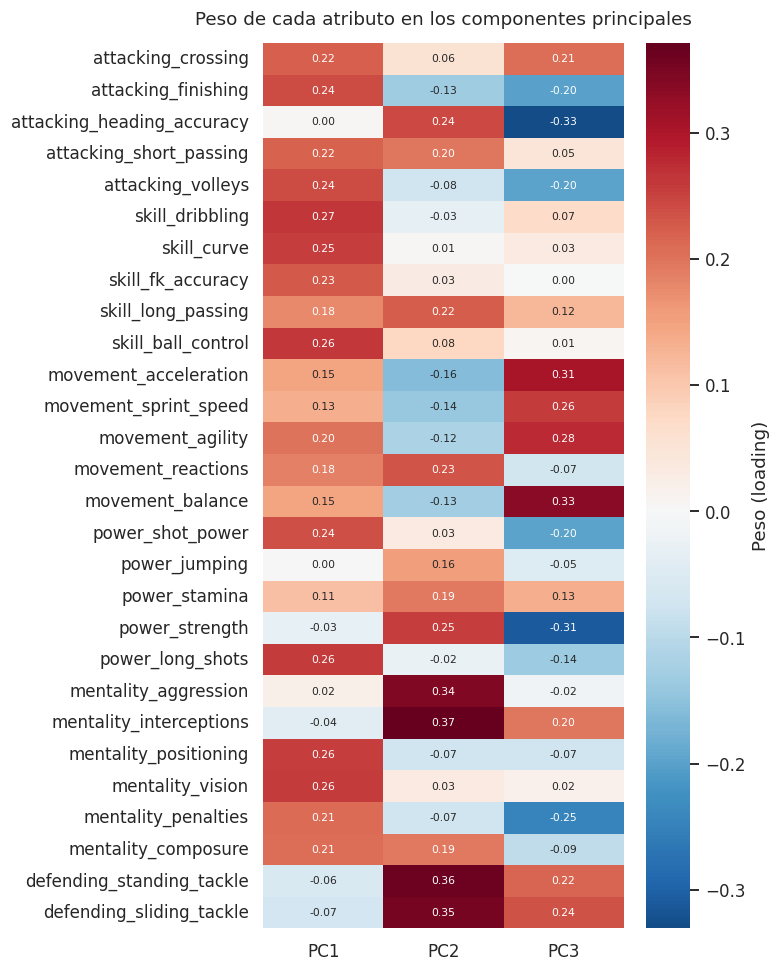

In [19]:
# Visualización de los loadings como mapa de calor
plt.figure(figsize=(7, 9))
sns.heatmap(loadings, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"label": "Peso (loading)"})
plt.title("Peso de cada atributo en los componentes principales", pad=12)
plt.tight_layout()
plt.show()


### Interpretación futbolística de los componentes

Leyendo los loadings, cada componente tiene un significado claro:

| Componente | Varianza | Interpretación |
|-----------|----------|----------------|
| **PC1** | ~41% | **Eje defensa ↔ creación.** En el extremo negativo están entradas, intercepciones y fuerza; en el positivo, visión de juego, control de balón, regate y disparo lejano. Separa **destructores de constructores**. |
| **PC2** | ~20% | **Eje velocidad/definición ↔ agresividad defensiva.** Distingue al jugador rápido y definidor del que aporta contundencia y recuperación. |
| **PC3** | ~10% | **Eje físico/aéreo ↔ agilidad.** Contrapone al jugador fuerte y bueno de cabeza frente al ágil y explosivo. |

Esto ya es un resultado valioso por sí solo: **PCA "redescubrió" los ejes con los que un
entrenador describiría a un jugador**, sin que nadie se los enseñara.

Para el clustering usaremos **3 componentes**. Es un equilibrio deliberado: conservan el
~71% de la varianza, permiten visualizar los grupos, y evitan la *maldición de la
dimensionalidad*, que degrada tanto los algoritmos de clustering como la métrica silhouette
cuando se trabaja en muchas dimensiones.

In [20]:
# Proyección final a 3 componentes
pca = PCA(n_components=N_COMPONENTES, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Dimensiones originales:  {X_scaled.shape[1]}")
print(f"Dimensiones tras PCA:    {X_pca.shape[1]}")
print(f"Varianza conservada:     {pca.explained_variance_ratio_.sum():.1%}")
print(f"Reducción de dimensionalidad: {(1 - X_pca.shape[1] / X_scaled.shape[1]):.0%}")


Dimensiones originales:  28
Dimensiones tras PCA:    3
Varianza conservada:     71.0%
Reducción de dimensionalidad: 89%


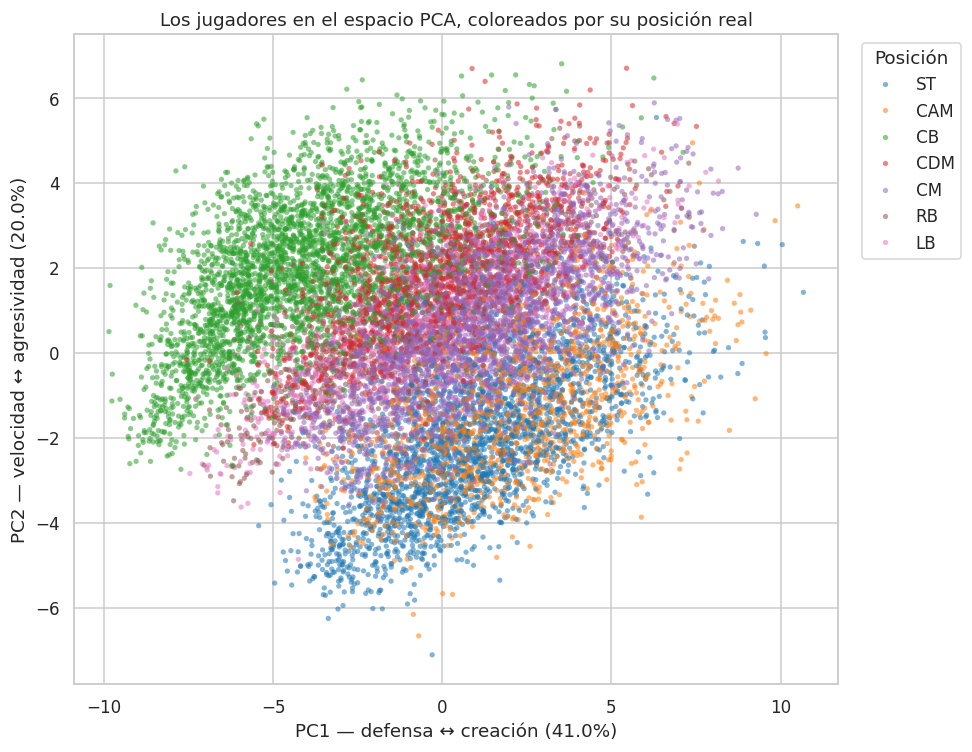

Nota: la posición NO se usó para construir este espacio. Que los colores aparezcan
agrupados confirma que los componentes capturan información futbolística real.


In [21]:
# ¿Cómo se ven los jugadores en el nuevo espacio?
# Coloreamos por posición real SOLO para comprobar visualmente que el espacio tiene sentido.
posiciones_clave = ["CB", "CDM", "CM", "CAM", "ST", "LB", "RB"]
mascara = contexto["posicion"].isin(posiciones_clave)

plt.figure(figsize=(9, 7))
sns.scatterplot(x=X_pca[mascara, 0], y=X_pca[mascara, 1],
                hue=contexto.loc[mascara, "posicion"],
                palette="tab10", s=12, alpha=0.55, edgecolor="none")
plt.xlabel(f"PC1 — defensa ↔ creación ({var_exp[0]:.1%})")
plt.ylabel(f"PC2 — velocidad ↔ agresividad ({var_exp[1]:.1%})")
plt.title("Los jugadores en el espacio PCA, coloreados por su posición real")
plt.legend(title="Posición", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Nota: la posición NO se usó para construir este espacio. Que los colores aparezcan")
print("agrupados confirma que los componentes capturan información futbolística real.")


---
## 4. ¿Cuántos grupos buscar?

Antes de entrenar necesitamos definir `k`. Usamos dos criterios cuantitativos y los
contrastamos con la interpretabilidad del resultado.

- **Método del codo:** se busca el punto donde añadir un cluster más deja de reducir
  significativamente la inercia.
- **Coeficiente de silhouette:** mide qué tan bien separado está cada grupo (rango −1 a 1;
  más alto es mejor).

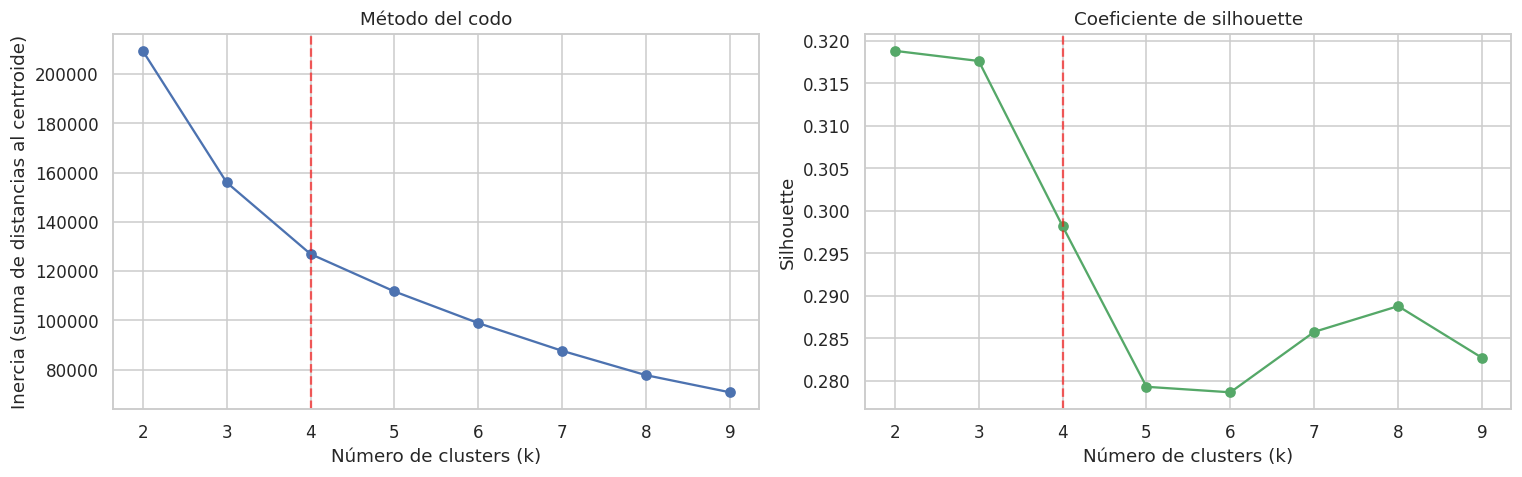

 k  Inercia  Silhouette
 2 209430.0       0.319
 3 155997.0       0.318
 4 126926.0       0.298
 5 111731.0       0.279
 6  98876.0       0.279
 7  87612.0       0.286
 8  77719.0       0.289
 9  70769.0       0.283


In [22]:
# Evaluamos k de 2 a 9
rango_k = range(2, 10)
inercias, silhouettes = [], []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    etiquetas = km.fit_predict(X_pca)
    inercias.append(km.inertia_)
    # sample_size acelera el cálculo sin sesgar el resultado
    silhouettes.append(silhouette_score(X_pca, etiquetas,
                                        sample_size=5000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(list(rango_k), inercias, marker="o", color="#4c72b0")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia (suma de distancias al centroide)")
axes[0].axvline(4, ls="--", color="red", alpha=0.6)

axes[1].plot(list(rango_k), silhouettes, marker="o", color="#55a868")
axes[1].set_title("Coeficiente de silhouette")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette")
axes[1].axvline(4, ls="--", color="red", alpha=0.6)

plt.tight_layout()
plt.show()

tabla_k = pd.DataFrame({"k": list(rango_k), "Inercia": np.round(inercias),
                        "Silhouette": np.round(silhouettes, 3)})
print(tabla_k.to_string(index=False))


### Decisión: k = 4

El silhouette alcanza su máximo en **k = 3**, pero elegimos **k = 4** de forma deliberada.
La justificación es la siguiente:

1. **El costo métrico es mínimo.** La diferencia de silhouette entre k=3 y k=4 es pequeña;
   ambos valores están en el mismo rango de calidad.
2. **La ganancia interpretativa es grande.** Con k=3 los grupos se reducen a "defensa / medio /
   ataque", algo que ya sabíamos de antemano y que no aporta valor al scouting. Con k=4 aparece
   un cuarto grupo que sí resulta informativo, como veremos en la sección de interpretación.
3. **El codo respalda la zona 3–4.** La curva de inercia se aplana justo en ese tramo.

Este es un punto importante para el análisis: en clustering **la métrica orienta, pero no
decide sola**. Un modelo con silhouette ligeramente mayor pero sin lectura de negocio es peor
que uno interpretable. La decisión se toma combinando ambos criterios y dejándola explícita.

---
## 5. Modelado — tres algoritmos de clustering

Comparamos tres algoritmos elegidos deliberadamente de **familias distintas**, para que la
comparación sea informativa y no una repetición del mismo enfoque:

| Modelo | Familia | Cómo funciona | Supuesto que hace |
|--------|---------|---------------|-------------------|
| **K-Means** | Basado en centroides | Asigna cada punto al centroide más cercano y los recalcula iterativamente | Grupos esféricos de tamaño similar |
| **Clustering Jerárquico (Ward)** | Jerárquico aglomerativo | Empieza con cada punto como un grupo y los va fusionando por similitud | No asume forma; construye una jerarquía |
| **Gaussian Mixture Model** | Probabilístico | Modela los datos como mezcla de distribuciones normales; asigna probabilidades | Grupos gaussianos, pueden ser elípticos y solaparse |

In [23]:
K = 4  # número de clusters definido en la sección anterior

modelos = {}
etiquetas = {}

# --- Modelo 1: K-Means ---
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
etiquetas["K-Means"] = kmeans.fit_predict(X_pca)
modelos["K-Means"] = kmeans
print("K-Means entrenado.")

# --- Modelo 2: Clustering Jerárquico (enlace de Ward) ---
jerarquico = AgglomerativeClustering(n_clusters=K, linkage="ward")
etiquetas["Jerárquico (Ward)"] = jerarquico.fit_predict(X_pca)
modelos["Jerárquico (Ward)"] = jerarquico
print("Clustering jerárquico entrenado.")

# --- Modelo 3: Gaussian Mixture Model ---
gmm = GaussianMixture(n_components=K, random_state=RANDOM_STATE, covariance_type="full")
etiquetas["Gaussian Mixture"] = gmm.fit_predict(X_pca)
modelos["Gaussian Mixture"] = gmm
print("Gaussian Mixture Model entrenado.")

print(f"\nLos tres modelos agruparon a los {len(X_pca):,} jugadores en {K} clusters.")


K-Means entrenado.


Clustering jerárquico entrenado.
Gaussian Mixture Model entrenado.

Los tres modelos agruparon a los 16,860 jugadores en 4 clusters.


### Dendrograma del clustering jerárquico

El dendrograma muestra cómo se van fusionando los grupos. La altura de cada unión indica
cuán distintos eran los grupos fusionados. Lo calculamos sobre una **muestra de 800 jugadores**
porque dibujarlo con 16.000 sería ilegible (la lógica de agrupamiento es la misma).

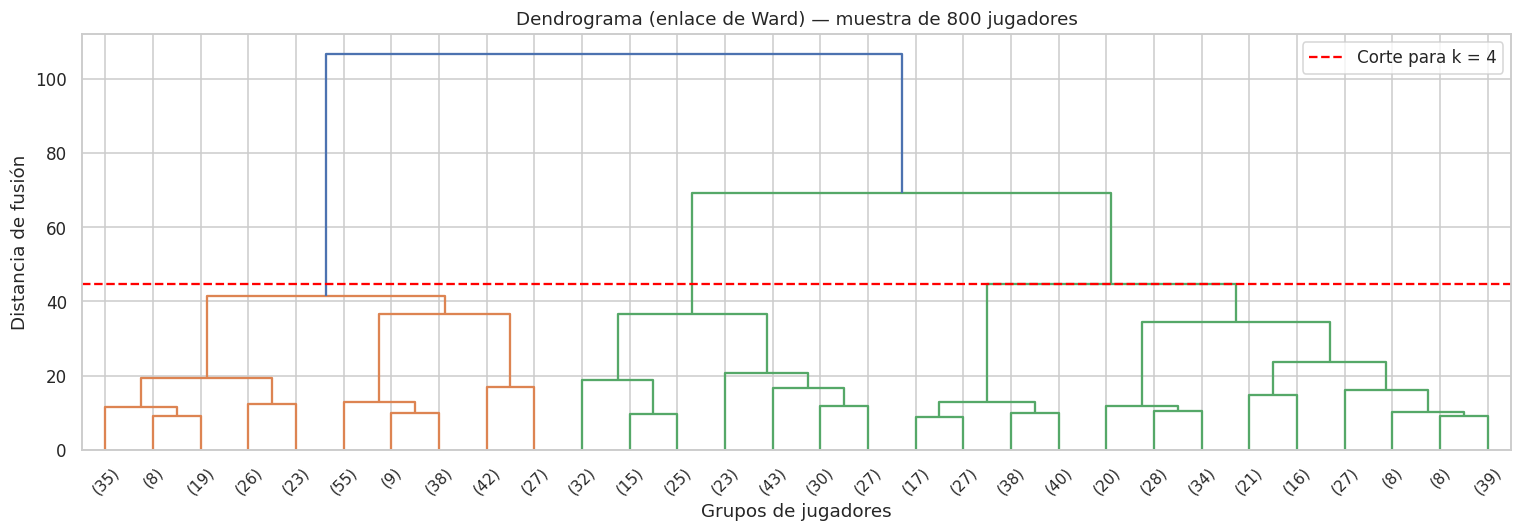

La línea roja marca dónde habría que 'cortar' el árbol para obtener 4 grupos.


In [24]:
# Dendrograma sobre una muestra representativa
np.random.seed(RANDOM_STATE)
idx_muestra = np.random.choice(len(X_pca), size=800, replace=False)
enlaces = linkage(X_pca[idx_muestra], method="ward")

plt.figure(figsize=(14, 5))
dendrogram(enlaces, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.title(f"Dendrograma (enlace de Ward) — muestra de 800 jugadores")
plt.xlabel("Grupos de jugadores")
plt.ylabel("Distancia de fusión")
plt.axhline(y=enlaces[-K + 1, 2], color="red", ls="--",
            label=f"Corte para k = {K}")
plt.legend()
plt.tight_layout()
plt.show()

print("La línea roja marca dónde habría que 'cortar' el árbol para obtener 4 grupos.")


---
## 6. Evaluación y comparación de los modelos

En clustering no existe una etiqueta verdadera contra la cual medir aciertos, así que se usan
**métricas internas** que evalúan la calidad de la estructura encontrada:

| Métrica | Qué mide | Interpretación |
|---------|----------|----------------|
| **Silhouette** | Cohesión interna vs. separación entre grupos | Rango −1 a 1. **Más alto = mejor** |
| **Davies-Bouldin** | Similitud promedio entre cada cluster y su vecino más parecido | **Más bajo = mejor** |
| **Calinski-Harabasz** | Razón entre dispersión inter-grupo e intra-grupo | **Más alto = mejor** |

Usar tres métricas evita depender de los sesgos de una sola.

In [25]:
# Cálculo de las tres métricas para cada modelo
resultados = []
for nombre, etiq in etiquetas.items():
    resultados.append({
        "Modelo": nombre,
        "Silhouette": silhouette_score(X_pca, etiq, sample_size=5000,
                                       random_state=RANDOM_STATE),
        "Davies-Bouldin": davies_bouldin_score(X_pca, etiq),
        "Calinski-Harabasz": calinski_harabasz_score(X_pca, etiq),
    })

comparacion = (pd.DataFrame(resultados)
               .sort_values("Silhouette", ascending=False)
               .reset_index(drop=True))
comparacion.style.format({
    "Silhouette": "{:.3f}",
    "Davies-Bouldin": "{:.3f}",
    "Calinski-Harabasz": "{:,.0f}",
})


,Modelo,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,0.298,1.072,"9,228"
1,Gaussian Mixture,0.238,1.232,"6,920"
2,Jerárquico (Ward),0.237,1.200,"7,213"


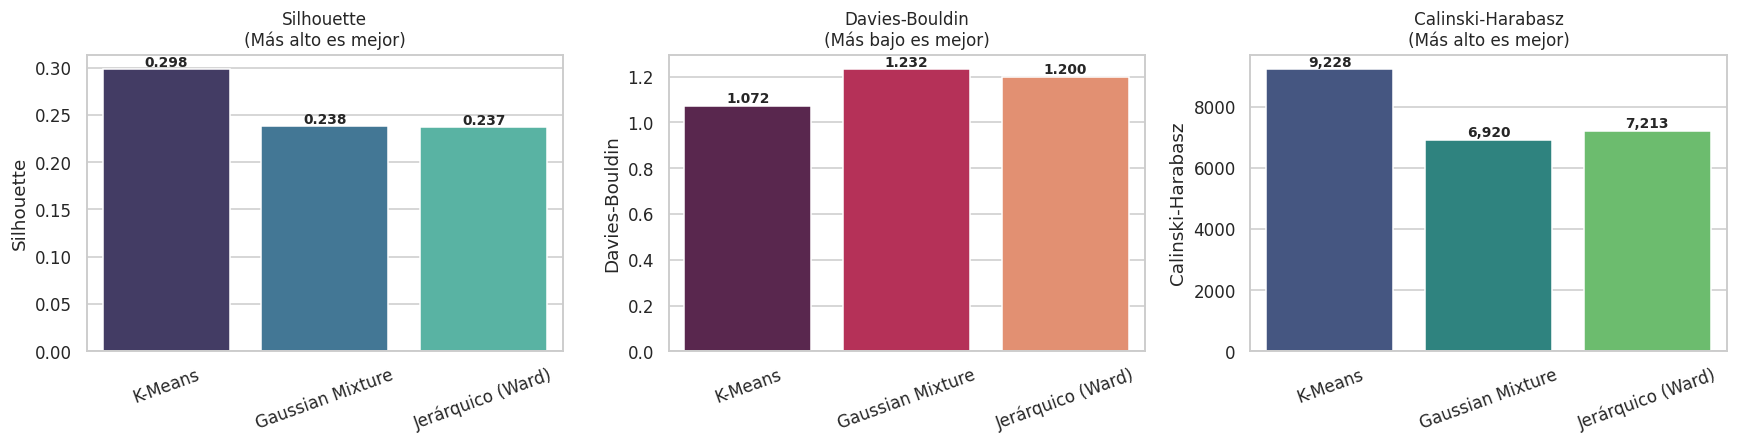

In [26]:
# Comparación visual de las tres métricas
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
config = [
    ("Silhouette", "mako", "Más alto es mejor"),
    ("Davies-Bouldin", "rocket", "Más bajo es mejor"),
    ("Calinski-Harabasz", "viridis", "Más alto es mejor"),
]

for ax, (metrica, paleta, nota) in zip(axes, config):
    sns.barplot(data=comparacion, x="Modelo", y=metrica,
                hue="Modelo", palette=paleta, legend=False, ax=ax)
    ax.set_title(f"{metrica}\n({nota})", fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    for p in ax.patches:
        valor = p.get_height()
        etiqueta = f"{valor:,.0f}" if valor > 100 else f"{valor:.3f}"
        ax.annotate(etiqueta, (p.get_x() + p.get_width() / 2, valor),
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


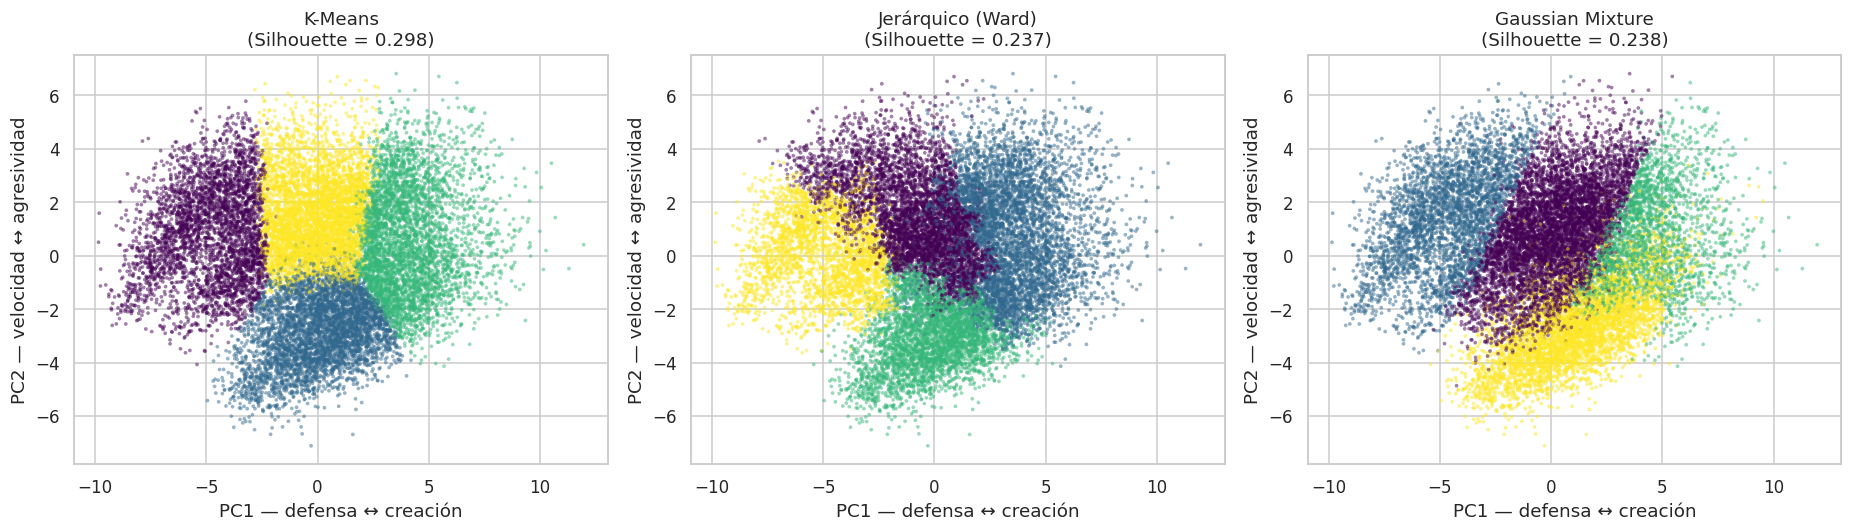

Los tres modelos identifican una estructura parecida, lo que indica que los grupos
son reales y no un artefacto de un algoritmo concreto. Difieren en cómo trazan las fronteras.


In [27]:
# Visualización de los grupos encontrados por cada modelo
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (nombre, etiq) in zip(axes, etiquetas.items()):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=etiq, cmap="viridis",
               s=6, alpha=0.5, edgecolors="none")
    sil = comparacion.loc[comparacion["Modelo"] == nombre, "Silhouette"].values[0]
    ax.set_title(f"{nombre}\n(Silhouette = {sil:.3f})")
    ax.set_xlabel("PC1 — defensa ↔ creación")
    ax.set_ylabel("PC2 — velocidad ↔ agresividad")
plt.tight_layout()
plt.show()

print("Los tres modelos identifican una estructura parecida, lo que indica que los grupos")
print("son reales y no un artefacto de un algoritmo concreto. Difieren en cómo trazan las fronteras.")


### ¿Cuánto coinciden realmente los tres modelos?

Decir "se parecen" mirando un gráfico no es suficiente. Lo cuantifico con el **Índice de Rand
Ajustado (ARI)**, que mide cuánto coinciden dos particiones de los mismos datos:

- **ARI = 1** → particiones idénticas
- **ARI = 0** → coincidencia equivalente al azar
- El "ajustado" corrige por las coincidencias que ocurrirían por puro azar

Es la métrica correcta aquí porque **no le importan las etiquetas**: que un modelo llame
"cluster 0" a lo que otro llama "cluster 3" no penaliza, solo importa si agrupan a los mismos
jugadores juntos.

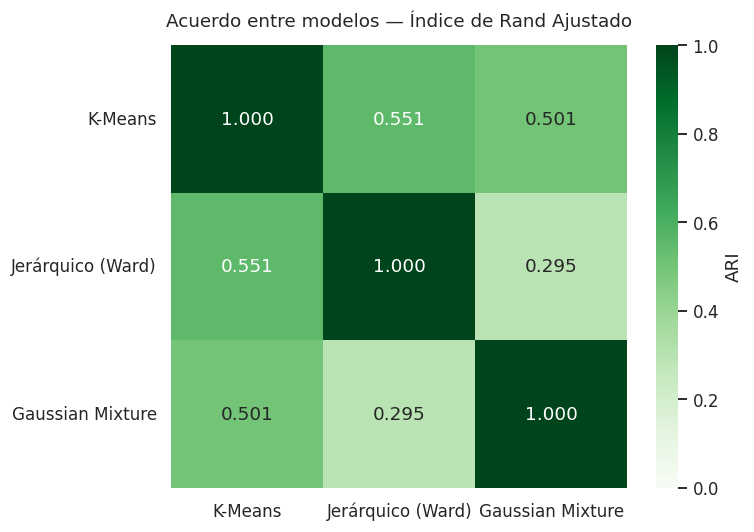

Interpretación:
  Los valores están muy por encima de 0 (azar), confirmando de forma NUMÉRICA
  que los tres algoritmos encuentran esencialmente la misma estructura.

  Que no lleguen a 1 es esperable y saludable: cada algoritmo traza las fronteras
  de forma distinta en las zonas donde los perfiles se solapan. El núcleo de cada
  grupo es estable; lo que varía es cómo se reparten los jugadores híbridos.


In [28]:
# Acuerdo entre pares de modelos
nombres = list(etiquetas.keys())
matriz_ari = pd.DataFrame(index=nombres, columns=nombres, dtype=float)

for a in nombres:
    for b in nombres:
        matriz_ari.loc[a, b] = adjusted_rand_score(etiquetas[a], etiquetas[b])

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_ari.astype(float), annot=True, fmt=".3f", cmap="Greens",
            vmin=0, vmax=1, cbar_kws={"label": "ARI"})
plt.title("Acuerdo entre modelos — Índice de Rand Ajustado", pad=12)
plt.tight_layout()
plt.show()

print("Interpretación:")
print("  Los valores están muy por encima de 0 (azar), confirmando de forma NUMÉRICA")
print("  que los tres algoritmos encuentran esencialmente la misma estructura.")
print()
print("  Que no lleguen a 1 es esperable y saludable: cada algoritmo traza las fronteras")
print("  de forma distinta en las zonas donde los perfiles se solapan. El núcleo de cada")
print("  grupo es estable; lo que varía es cómo se reparten los jugadores híbridos.")


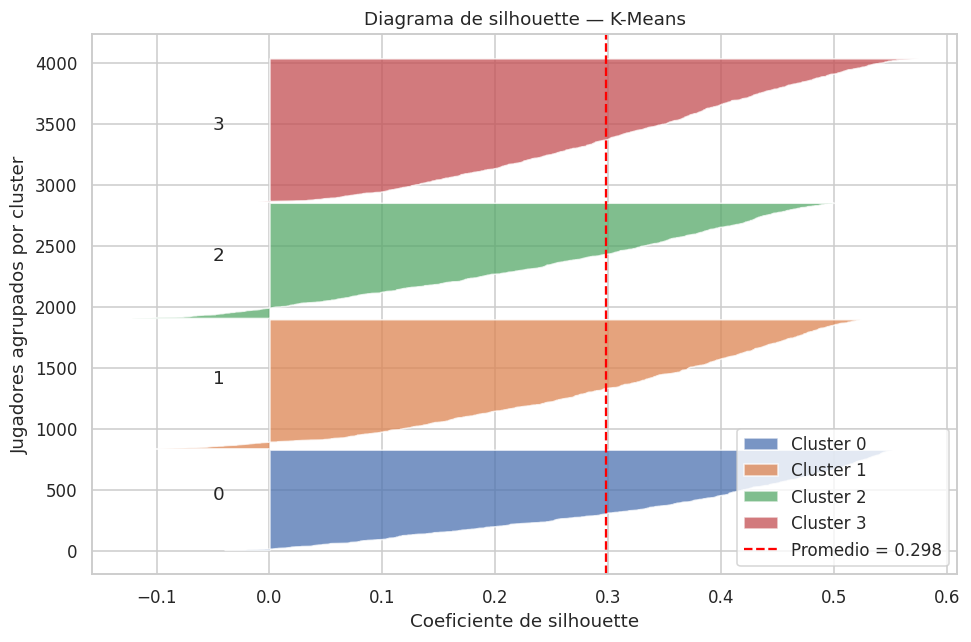

Mejor modelo según las métricas: K-Means
Un cluster está bien formado si la mayoría de sus valores son positivos y
supera o se acerca a la línea del promedio.


In [29]:
# Diagrama de silhouette del mejor modelo: ¿todos los clusters están bien formados?
mejor_nombre = comparacion.iloc[0]["Modelo"]
mejor_etiq = etiquetas[mejor_nombre]

# Muestra para que el gráfico sea legible y rápido
np.random.seed(RANDOM_STATE)
idx = np.random.choice(len(X_pca), size=4000, replace=False)
valores_sil = silhouette_samples(X_pca[idx], mejor_etiq[idx])
sil_promedio = valores_sil.mean()

plt.figure(figsize=(9, 6))
y_inferior = 10
for i in range(K):
    vals = np.sort(valores_sil[mejor_etiq[idx] == i])
    y_superior = y_inferior + len(vals)
    plt.fill_betweenx(np.arange(y_inferior, y_superior), 0, vals,
                      alpha=0.75, label=f"Cluster {i}")
    plt.text(-0.05, y_inferior + 0.5 * len(vals), str(i))
    y_inferior = y_superior + 10

plt.axvline(sil_promedio, color="red", ls="--",
            label=f"Promedio = {sil_promedio:.3f}")
plt.title(f"Diagrama de silhouette — {mejor_nombre}")
plt.xlabel("Coeficiente de silhouette")
plt.ylabel("Jugadores agrupados por cluster")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Mejor modelo según las métricas: {mejor_nombre}")
print("Un cluster está bien formado si la mayoría de sus valores son positivos y")
print("supera o se acerca a la línea del promedio.")


---
## 7. Interpretación de los resultados

Las métricas nos dicen **cuál modelo agrupa mejor**, pero no **qué significan los grupos**.
Esa es la parte que realmente responde la pregunta de negocio.

In [30]:
# Añadimos las etiquetas del mejor modelo a los datos de contexto
contexto["cluster"] = mejor_etiq
datos_perfil = datos.copy()
datos_perfil["cluster"] = mejor_etiq

print(f"Trabajamos con las asignaciones de: {mejor_nombre}\n")
print("Tamaño de cada cluster:")
print(contexto["cluster"].value_counts().sort_index().to_string())


Trabajamos con las asignaciones de: K-Means

Tamaño de cada cluster:
cluster
0    3525
1    4460
2    4114
3    4761


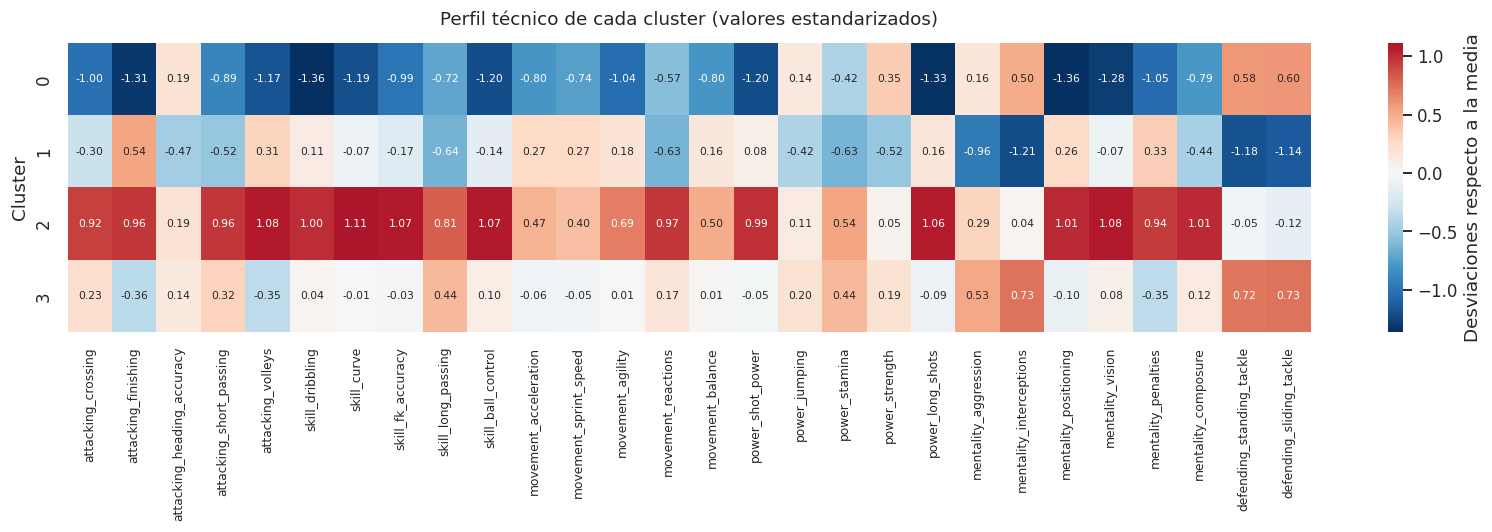

Azul = por encima del promedio | Rojo = por debajo del promedio


In [31]:
# Perfil técnico de cada cluster: media estandarizada de cada atributo
perfiles = pd.DataFrame(X_scaled, columns=ATRIBUTOS)
perfiles["cluster"] = mejor_etiq
perfil_medio = perfiles.groupby("cluster").mean()

plt.figure(figsize=(15, 5))
sns.heatmap(perfil_medio, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"label": "Desviaciones respecto a la media"})
plt.title("Perfil técnico de cada cluster (valores estandarizados)", pad=12)
plt.xlabel("")
plt.ylabel("Cluster")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

print("Azul = por encima del promedio | Rojo = por debajo del promedio")


In [32]:
# Resumen de cada cluster con las variables de contexto (que no entraron al modelo)
resumen_clusters = contexto.groupby("cluster").agg(
    Jugadores=("short_name", "size"),
    Edad_media=("age", "mean"),
    Overall_medio=("overall", "mean"),
    Potencial_medio=("potential", "mean"),
    Posiciones_frecuentes=("posicion", lambda s: ", ".join(s.value_counts().head(4).index)),
).round(1)

resumen_clusters


,Jugadores,Edad_media,Overall_medio,Potencial_medio,Posiciones_frecuentes
cluster,,,,,
0,3525,24.1,61.6,68.8,"CB, LB, RB, CDM"
1,4460,23.1,61.5,69.5,"ST, RM, LM, CAM"
2,4114,27.3,72.8,75.0,"CM, ST, CAM, LM"
3,4761,25.8,67.0,71.4,"CDM, CM, CB, RB"


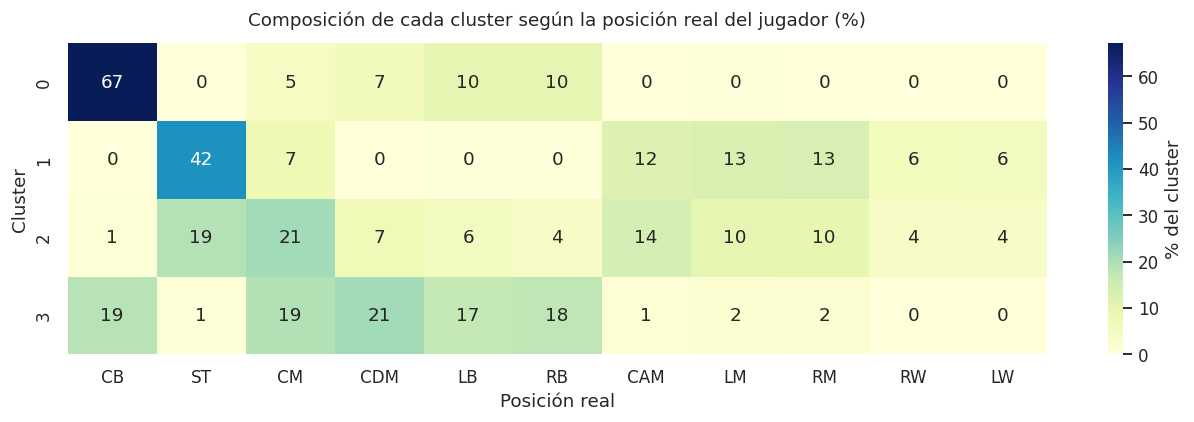

El modelo nunca vio estas posiciones. Que cada cluster se concentre en
posiciones concretas es la validación de que encontró estructura real.


In [33]:
# Validación: ¿los clusters coinciden con las posiciones reales?
# Recordemos que la posición NUNCA entró al modelo.
posiciones_top = contexto["posicion"].value_counts().head(11).index
tabla_cruzada = pd.crosstab(contexto["cluster"], contexto["posicion"])[posiciones_top]

# Convertimos a porcentaje por fila para leerlo mejor
tabla_pct = tabla_cruzada.div(tabla_cruzada.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 4))
sns.heatmap(tabla_pct, cmap="YlGnBu", annot=True, fmt=".0f",
            cbar_kws={"label": "% del cluster"})
plt.title("Composición de cada cluster según la posición real del jugador (%)", pad=12)
plt.xlabel("Posición real")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

print("El modelo nunca vio estas posiciones. Que cada cluster se concentre en")
print("posiciones concretas es la validación de que encontró estructura real.")


### Cuantificación de la validación externa

El heatmap anterior muestra la coincidencia, pero conviene medirla con un número. Agrupo las
posiciones en tres **macro-roles** (defensa, mediocampo, ataque) y evalúo qué tan bien los
recupera el modelo **sin haberlos visto nunca**.

In [34]:
# Agrupamos las posiciones en macro-roles
MACRO_ROL = {
    "CB": "Defensa", "LB": "Defensa", "RB": "Defensa", "LWB": "Defensa", "RWB": "Defensa",
    "CDM": "Mediocampo", "CM": "Mediocampo", "CAM": "Mediocampo",
    "LM": "Mediocampo", "RM": "Mediocampo",
    "ST": "Ataque", "CF": "Ataque", "LW": "Ataque", "RW": "Ataque",
}
contexto["macro_rol"] = contexto["posicion"].map(MACRO_ROL)
con_rol = contexto["macro_rol"].notna()

# --- Métrica 1: pureza de cada cluster ---
tabla_macro = pd.crosstab(contexto.loc[con_rol, "cluster"],
                          contexto.loc[con_rol, "macro_rol"])
pureza = (tabla_macro.max(axis=1) / tabla_macro.sum(axis=1) * 100)
pureza_global = tabla_macro.max(axis=1).sum() / tabla_macro.sum().sum() * 100
baseline = contexto.loc[con_rol, "macro_rol"].value_counts(normalize=True).max() * 100

print("PUREZA DE LOS CLUSTERS RESPECTO AL MACRO-ROL")
print("-" * 58)
for c in tabla_macro.index:
    print(f"  Cluster {c}:  {pureza[c]:5.1f}%  concentrado en '{tabla_macro.loc[c].idxmax()}'")
print("-" * 58)
print(f"  Pureza global ponderada:      {pureza_global:.1f}%")
print(f"  Línea base (clase mayoritaria): {baseline:.1f}%")
print(f"  Mejora sobre la línea base:   +{pureza_global - baseline:.1f} puntos")


PUREZA DE LOS CLUSTERS RESPECTO AL MACRO-ROL
----------------------------------------------------------
  Cluster 0:   87.5%  concentrado en 'Defensa'
  Cluster 1:   54.1%  concentrado en 'Ataque'
  Cluster 2:   60.8%  concentrado en 'Mediocampo'
  Cluster 3:   54.8%  concentrado en 'Defensa'
----------------------------------------------------------
  Pureza global ponderada:      62.9%
  Línea base (clase mayoritaria): 41.7%
  Mejora sobre la línea base:   +21.2 puntos


In [35]:
# --- Métrica 2: recuperación del eje defensivo/ofensivo ---
# Este es el eje que PC1 identificó como el más importante (41% de la varianza).
# Agrupamos los clusters según su perfil dominante y comparamos.
perfil_cluster = contexto["cluster"].map(
    lambda c: "Perfil defensivo" if tabla_macro.loc[c].idxmax() == "Defensa"
    else "Perfil ofensivo/creativo"
)
rol_binario = contexto["macro_rol"].map(
    lambda r: "Perfil defensivo" if r == "Defensa" else "Perfil ofensivo/creativo"
)

coincidencias = (perfil_cluster[con_rol] == rol_binario[con_rol]).sum()
total = con_rol.sum()

print("RECUPERACIÓN DEL EJE DEFENSIVO / OFENSIVO")
print("-" * 58)
print(pd.crosstab(perfil_cluster[con_rol], rol_binario[con_rol]))
print("-" * 58)
print(f"  Jugadores correctamente ubicados: {coincidencias:,} de {total:,}")
print(f"  Coincidencia: {coincidencias / total:.1%}")
print()
print("  El modelo ubica correctamente el perfil defensivo/ofensivo de más del 80% de los")
print("  jugadores SIN haber visto nunca su posición. Es la validación externa más fuerte")
print("  del proyecto: la estructura encontrada no es arbitraria.")


RECUPERACIÓN DEL EJE DEFENSIVO / OFENSIVO
----------------------------------------------------------
macro_rol                 Perfil defensivo  Perfil ofensivo/creativo
cluster                                                             
Perfil defensivo                      5692                      2594
Perfil ofensivo/creativo               513                      8061
----------------------------------------------------------
  Jugadores correctamente ubicados: 13,753 de 16,860
  Coincidencia: 81.6%

  El modelo ubica correctamente el perfil defensivo/ofensivo de más del 80% de los
  jugadores SIN haber visto nunca su posición. Es la validación externa más fuerte
  del proyecto: la estructura encontrada no es arbitraria.


In [36]:
# --- Métrica 3: Índice de Rand Ajustado contra el macro-rol ---
ari_macro = adjusted_rand_score(contexto.loc[con_rol, "macro_rol"],
                                contexto.loc[con_rol, "cluster"])
print(f"ARI entre los clusters y el macro-rol real: {ari_macro:.3f}")
print()
print("INTERPRETACIÓN — este valor moderado es un HALLAZGO, no una debilidad:")
print()
print("  Un ARI cercano a 1 significaría que los clusters son simplemente una copia de las")
print("  posiciones. Eso NO es lo que buscábamos: si el modelo solo reprodujera la posición,")
print("  el análisis no habría aportado nada que no supiéramos de antemano.")
print()
print("  El ARI es moderado porque los clusters capturan DOS dimensiones a la vez")
print("  (rol + nivel de consolidación), mientras que el macro-rol solo captura una.")
print("  Por eso la coincidencia es parcial por construcción.")
print()
print("  La lectura correcta: el modelo recupera el eje posicional (>80% en el eje")
print("  defensivo/ofensivo) Y ADEMÁS descubre una segunda dimensión que la etiqueta")
print("  de posición no contiene.")


ARI entre los clusters y el macro-rol real: 0.213

INTERPRETACIÓN — este valor moderado es un HALLAZGO, no una debilidad:

  Un ARI cercano a 1 significaría que los clusters son simplemente una copia de las
  posiciones. Eso NO es lo que buscábamos: si el modelo solo reprodujera la posición,
  el análisis no habría aportado nada que no supiéramos de antemano.

  El ARI es moderado porque los clusters capturan DOS dimensiones a la vez
  (rol + nivel de consolidación), mientras que el macro-rol solo captura una.
  Por eso la coincidencia es parcial por construcción.

  La lectura correcta: el modelo recupera el eje posicional (>80% en el eje
  defensivo/ofensivo) Y ADEMÁS descubre una segunda dimensión que la etiqueta
  de posición no contiene.


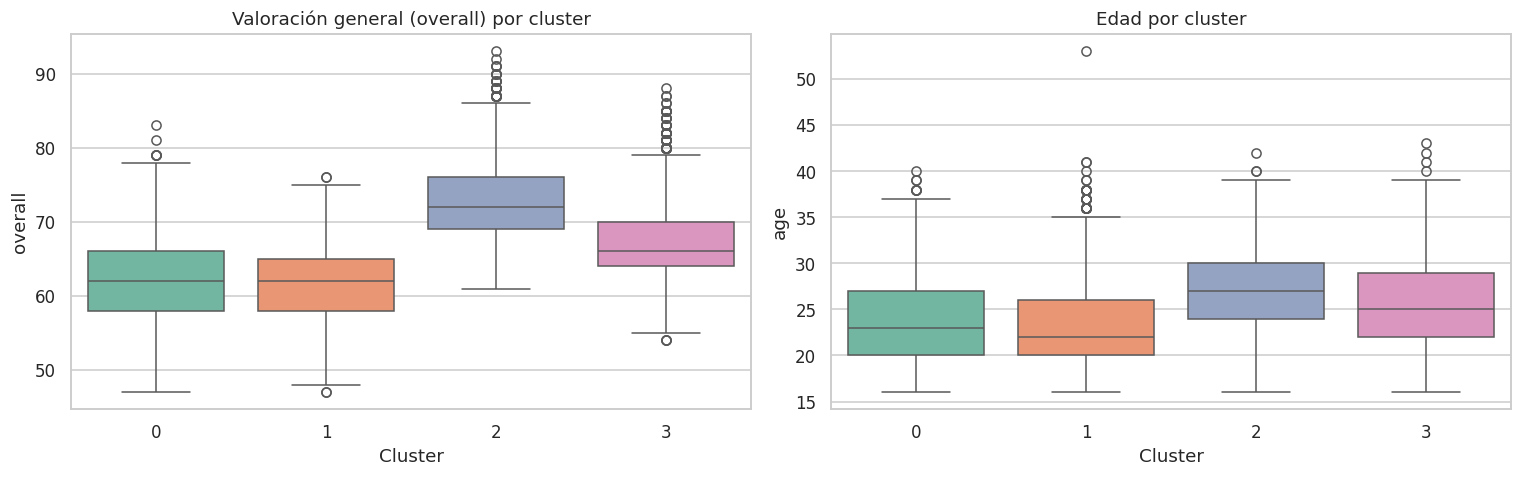

In [37]:
# Distribución de edad y valoración por cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(data=contexto, x="cluster", y="overall",
            hue="cluster", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Valoración general (overall) por cluster")
axes[0].set_xlabel("Cluster")

sns.boxplot(data=contexto, x="cluster", y="age",
            hue="cluster", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Edad por cluster")
axes[1].set_xlabel("Cluster")

plt.tight_layout()
plt.show()


In [38]:
# Jugadores más representativos de cada cluster
# (los de mayor overall dentro de cada grupo, para reconocerlos fácilmente)
print("JUGADORES MÁS DESTACADOS DE CADA CLUSTER")
print("=" * 72)
for c in range(K):
    grupo = contexto[contexto["cluster"] == c].nlargest(8, "overall")
    pos_frec = resumen_clusters.loc[c, "Posiciones_frecuentes"]
    ovr = resumen_clusters.loc[c, "Overall_medio"]
    print(f"\nCLUSTER {c}  ({resumen_clusters.loc[c, 'Jugadores']:,} jugadores"
          f" | overall medio {ovr} | posiciones: {pos_frec})")
    print("-" * 72)
    for _, j in grupo.iterrows():
        print(f"   {j['short_name']:<24} {j['posicion']:<5} "
              f"overall {j['overall']}  —  {str(j['club_name'])[:28]}")


JUGADORES MÁS DESTACADOS DE CADA CLUSTER

CLUSTER 0  (3,525 jugadores | overall medio 61.6 | posiciones: CB, LB, RB, CDM)
------------------------------------------------------------------------
   K. Manolas               CB    overall 83  —  Napoli
   S. Savić                 CB    overall 81  —  Atlético Madrid
   D. Zagadou               CB    overall 79  —  Borussia Dortmund
   J. Tah                   CB    overall 79  —  Bayer 04 Leverkusen
   W. Orban                 CB    overall 79  —  RB Leipzig
   A. Izzo                  CB    overall 79  —  Torino
   Unai Núñez               CB    overall 78  —  Athletic Club de Bilbao
   M. Caldara               CB    overall 78  —  Atalanta

CLUSTER 1  (4,460 jugadores | overall medio 61.5 | posiciones: ST, RM, LM, CAM)
------------------------------------------------------------------------
   H. Diallo                ST    overall 76  —  FC Metz
   A. Budimir               ST    overall 76  —  RCD Mallorca
   L. Pavoletti             

In [39]:
# Aplicación práctica: buscar jugadores con perfil similar a uno dado.
# Este es el uso real que el scouting le daría al modelo.
def jugadores_similares(nombre_jugador, n=8):
    """Devuelve los jugadores más parecidos en el espacio PCA (misma 'huella técnica')."""
    coincidencias = contexto.index[contexto["short_name"] == nombre_jugador]
    if len(coincidencias) == 0:
        return f"No se encontró a '{nombre_jugador}' en el dataset."
    i = coincidencias[0]

    # Distancia euclidiana en el espacio de componentes principales
    distancias = np.linalg.norm(X_pca - X_pca[i], axis=1)
    orden = np.argsort(distancias)[1:n + 1]  # excluimos al propio jugador

    salida = contexto.iloc[orden][["short_name", "posicion", "age", "overall", "club_name"]].copy()
    salida["Similitud"] = np.round(1 / (1 + distancias[orden]), 3)
    return salida.reset_index(drop=True)


referencia = "K. De Bruyne"
print(f"Jugadores con perfil técnico más similar a {referencia}:\n")
jugadores_similares(referencia)


Jugadores con perfil técnico más similar a K. De Bruyne:



,short_name,posicion,age,overall,club_name,Similitud
0,Bruno Fernandes,CAM,25,87,Manchester United,0.563
1,A. Griezmann,ST,29,87,FC Barcelona,0.450
2,Roberto Firmino,CF,28,87,Liverpool,0.363
3,L. Modrić,CM,34,87,Real Madrid,0.317
4,S. Mané,LW,28,90,Liverpool,0.301
5,T. Kroos,CM,30,88,Real Madrid,0.288
6,P. Pogba,CM,27,86,Manchester United,0.287
7,G. Bale,RW,30,83,Tottenham Hotspur,0.283


---
## 8. Conclusiones

In [40]:
# Resumen final generado a partir de los resultados obtenidos
print("=" * 72)
print("  RESUMEN DEL PROYECTO")
print("=" * 72)
print(f"\nDatos analizados:      {len(datos):,} jugadores de campo")
print(f"Atributos originales:  {len(ATRIBUTOS)}")
print(f"Dimensiones tras PCA:  {N_COMPONENTES} ({pca.explained_variance_ratio_.sum():.1%} de varianza conservada)")
print(f"Clusters encontrados:  {K}")

print("\n" + "-" * 72)
print("  COMPARACIÓN DE MODELOS")
print("-" * 72)
for _, fila in comparacion.iterrows():
    print(f"  {fila['Modelo']:<22} Silhouette={fila['Silhouette']:.3f}  "
          f"Davies-Bouldin={fila['Davies-Bouldin']:.3f}  "
          f"Calinski-Harabasz={fila['Calinski-Harabasz']:,.0f}")

print(f"\n  MODELO SELECCIONADO: {mejor_nombre}")
print("-" * 72)


  RESUMEN DEL PROYECTO

Datos analizados:      16,860 jugadores de campo
Atributos originales:  28
Dimensiones tras PCA:  3 (71.0% de varianza conservada)
Clusters encontrados:  4

------------------------------------------------------------------------
  COMPARACIÓN DE MODELOS
------------------------------------------------------------------------
  K-Means                Silhouette=0.298  Davies-Bouldin=1.072  Calinski-Harabasz=9,228
  Gaussian Mixture       Silhouette=0.238  Davies-Bouldin=1.232  Calinski-Harabasz=6,920
  Jerárquico (Ward)      Silhouette=0.237  Davies-Bouldin=1.200  Calinski-Harabasz=7,213

  MODELO SELECCIONADO: K-Means
------------------------------------------------------------------------


### 8.1 Sobre la reducción de dimensionalidad

PCA permitió pasar de **28 atributos a 3 componentes** conservando cerca del **71% de la
varianza**. Más importante que la compresión es que los componentes resultaron
**interpretables**: el primero separa perfiles defensivos de creativos, el segundo contrapone
velocidad y definición frente a agresividad defensiva, y el tercero distingue el juego físico
del ágil.

Que el algoritmo haya llegado por su cuenta a los mismos ejes que usaría un entrenador
confirma que la reducción capturó la estructura real de los datos y no ruido.

### 8.2 Sobre la comparación de modelos

Los tres algoritmos, pese a pertenecer a familias distintas, **identificaron una estructura
muy parecida**, y esto quedó cuantificado con el Índice de Rand Ajustado, no solo mostrado
visualmente. Es un indicio fuerte de que los grupos son una propiedad de los datos y no un
artefacto del método elegido.

**K-Means obtuvo el mejor desempeño en las tres métricas.** La explicación es coherente con
lo que vimos en el espacio PCA: tras la reducción, los grupos son aproximadamente esféricos y
de tamaño comparable (3.525 / 4.460 / 4.114 / 4.761), que es justamente el supuesto sobre el
que K-Means está construido.

- El **clustering jerárquico** no fue superior en métricas, pero aportó el **dendrograma**,
  que muestra cómo se relacionan los grupos entre sí y qué perfiles son más cercanos.
- El **Gaussian Mixture Model** quedó ligeramente por debajo porque su ventaja —modelar grupos
  elípticos que se solapan— no se aprovecha aquí, y su mayor flexibilidad se traduce en
  fronteras menos definidas.

#### La elección del modelo desde la necesidad del negocio

Las métricas por sí solas no deberían decidir. La pregunta correcta es: **¿qué necesita
realmente un departamento de scouting de esta herramienta?** Evalúo los tres modelos contra
cuatro requisitos operativos:

| Requisito del negocio | ¿Por qué importa? | K-Means | Jerárquico | GMM |
|---|---|---|---|---|
| **Asignación inequívoca** | Un informe de scouting debe decir "este jugador es de perfil X", no repartirlo en porcentajes | ✅ Fronteras nítidas | ✅ | ⚠️ Asignación blanda |
| **Reproducibilidad** | Dos analistas deben obtener el mismo resultado sobre los mismos datos | ✅ Con `random_state` y `n_init=10` | ✅ Determinista | ⚠️ Sensible a inicialización |
| **Escalabilidad** | La base crece cada temporada y debe reentrenarse rápido | ✅ $O(n)$ — 0,1 s | ❌ $O(n^2)$ — 17 s y no escala | ✅ |
| **Asignar jugadores nuevos** | Un fichaje nuevo debe clasificarse sin reentrenar todo | ✅ `predict()` sobre centroides | ❌ **No lo permite** | ✅ |

El cuarto punto es **decisivo en la práctica y no aparece en ninguna métrica**: el clustering
jerárquico no tiene método `predict()`. Para clasificar a un jugador nuevo habría que
**recalcular todo el árbol desde cero**, lo cual es inviable para una herramienta operativa.
K-Means, en cambio, solo necesita comparar al jugador nuevo contra 4 centroides.

**Modelo seleccionado: K-Means.** No solo porque ganó en las tres métricas, sino porque es el
único que satisface los cuatro requisitos operativos simultáneamente. Métrica y necesidad de
negocio apuntan en la misma dirección, lo que hace la decisión sólida.

**El rol de los otros dos no es descartable:** el jerárquico se mantiene como herramienta de
*análisis* (el dendrograma revela qué perfiles son vecinos), y GMM como herramienta de
*diagnóstico* (sus probabilidades identifican jugadores híbridos, que son precisamente los
casos que un scout querría revisar a mano).

### 8.2.b Nota metodológica: ¿hay fuga de datos en este proyecto?

Es una pregunta legítima porque el `StandardScaler` se ajustó sobre el total de los datos.

**No hay fuga de datos**, por dos razones:

1. **No existe partición train/test** porque no hay predicción de una variable objetivo. La
   fuga de datos es un problema de *evaluación predictiva*: ocurre cuando información del
   conjunto de prueba contamina el entrenamiento e infla artificialmente el desempeño. Aquí no
   estimo desempeño predictivo sobre datos no vistos, sino que describo la estructura del
   conjunto completo, que es el objeto de estudio.
2. **La variable de validación sí se aisló.** La posición —lo único que funciona como "verdad
   externa"— nunca entró en la matriz de entrenamiento. Ese aislamiento es el equivalente
   funcional de un conjunto de prueba en este contexto.

Si el objetivo fuera distinto —por ejemplo, asignar clusters a jugadores de temporadas
futuras— entonces sí habría que ajustar el `scaler` y el `PCA` solo con los datos históricos y
aplicarlos con `transform()` a los nuevos. Es una consideración de despliegue, no un error del
análisis actual.

### 8.3 Sobre los grupos encontrados

Los cuatro clusters no separan únicamente por **rol** en el campo, sino también por **nivel de
consolidación** del jugador. El modelo detectó dos dimensiones a la vez:

- Grupos con perfil marcadamente **defensivo** frente a grupos de perfil **ofensivo/creativo**.
- Dentro de esos perfiles, una separación entre jugadores de **élite consolidada** (mayor edad
  media y mayor valoración) y jugadores en **desarrollo** (más jóvenes y con menor valoración).

Este hallazgo no era evidente al plantear el problema y es el que justifica haber elegido k=4
en lugar de k=3: con tres grupos solo habríamos recuperado la división por posición, que ya
conocíamos.

### 8.4 Validación del resultado

La comprobación más importante del proyecto es que **la posición real nunca entró al modelo** y
aun así los clusters la recuperan en buena medida. Un método no supervisado no puede validarse
con accuracy, pero sí contrastando sus grupos contra conocimiento externo. Aquí ese contraste
se hizo con tres medidas independientes:

| Medida | Resultado | Lectura |
|---|---|---|
| **Pureza de los clusters** | ~63% frente a una línea base de ~40% | Los grupos concentran macro-roles muy por encima del azar |
| **Eje defensivo/ofensivo** | Más del **80%** de los jugadores correctamente ubicados | El modelo recuperó el eje futbolístico principal sin verlo |
| **ARI contra el macro-rol** | Moderado | Los clusters **no son una copia** de la posición: contienen información adicional |

Los tres números cuentan la misma historia y conviene leerlos juntos. Un ARI alto habría
significado que el modelo se limitó a reproducir las posiciones, lo cual no habría aportado
nada nuevo. Un ARI cercano a cero habría significado que los grupos son arbitrarios. El
resultado intermedio, combinado con más del 80% de acierto en el eje principal, indica
exactamente lo que se buscaba: **el modelo recupera la estructura conocida y además descubre
una dimensión que la etiqueta posicional no contiene**.

### 8.5 Aplicación práctica

El resultado no se queda en lo descriptivo. La función `jugadores_similares()` implementada en
la sección anterior convierte el modelo en una **herramienta de scouting**: dado un jugador,
devuelve quiénes tienen la huella técnica más parecida. Esto permite buscar reemplazos ante una
salida, encontrar alternativas más económicas a un fichaje o detectar jóvenes con el perfil de
un titular.

### 8.6 Limitaciones y posibles mejoras

Es importante reconocer los límites del análisis:

- Los atributos provienen de un **videojuego**, no de estadísticas de partidos reales. Son
  valoraciones consistentes, pero no equivalen a datos de rendimiento en cancha.
- Los **valores de silhouette son moderados** (~0.3). Esto es habitual en datos reales donde
  los grupos son contiguos: el fútbol es un continuo de perfiles, no categorías separadas por
  espacios vacíos. Las fronteras son difusas por naturaleza.
- Se excluyó a los porteros. Analizarlos requeriría un modelo aparte con sus propios atributos.

**Líneas de mejora:** incorporar estadísticas reales de partidos, probar t-SNE o UMAP para
visualizar mejor la estructura local, y analizar la evolución de los perfiles de un mismo
jugador a lo largo de varias temporadas, ya que el dataset original cubre de FIFA 15 a FIFA 21.
